# Mini-projet Data Mining - Prédiction d'Attrition

# Phase 1 : Business Understanding & Data Understanding

## 1.1 Contexte du problème
L'objectif est de prédire si un employé va quitter l'entreprise (attrition) 
afin de permettre à la direction de mettre en place des actions de rétention.

## 1.2 Objectifs du projet
- Identifier les facteurs clés influençant l'attrition
- Construire un modèle de classification performant
- Déployer un outil d'aide à la décision

In [25]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Chargement et première analyse
df = pd.read_csv('dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Forme du dataset :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nTypes de données :")
print(df.dtypes.value_counts())

Forme du dataset : (1470, 35)

Colonnes : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Types de données :
int64     26
object     9
Name: count, dtype: int64


## 1.3 Analyse de la variable cible (Attrition)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Pourcentage :
Attrition
No     83.877551
Yes    16.122449
Name: count, dtype: float64


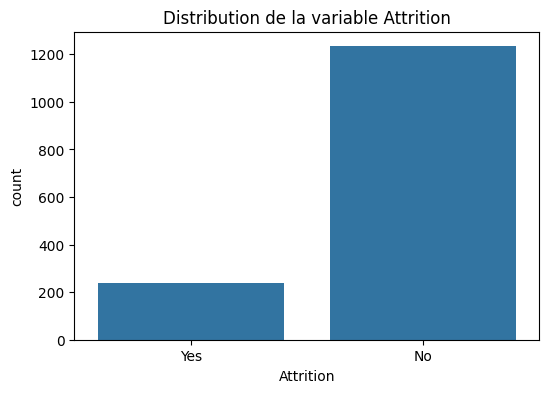

In [27]:
# Distribution de la cible
target_counts = df['Attrition'].value_counts()
print(target_counts)
print(f"\nPourcentage :\n{target_counts / len(df) * 100}")

# Visualisation
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Attrition')
plt.title('Distribution de la variable Attrition')
plt.show()

### Résultats de l'analyse
- **Déséquilibre des classes** : 84% "No" vs 16% "Yes"
- **Conséquence** : Nécessité d'utiliser SMOTE et la métrique MCC (cf. cours slide 85)

## 1.4 Analyse des valeurs manquantes

In [28]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsIn

## 1.5 Statistiques descriptives des variables numériques


In [29]:
# Statistiques descriptives
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 1.6 Aperçu des données

In [30]:
# Premières lignes
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1.7 Identification des colonnes inutiles (pour Phase 2)


In [31]:
# Colonnes constantes ou identifiants
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours']
id_cols = ['EmployeeNumber']
print("Colonnes à supprimer :", constant_cols + id_cols)

Colonnes à supprimer : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


# Phase 2 : Data Preparation

## 2.1 Suppression des colonnes inutiles

In [32]:
# Suppression des colonnes constantes et identifiants
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop)
print(f"Colonnes après suppression : {df_clean.shape[1]}")
print(f"Colonnes restantes : {df_clean.columns.tolist()}")

Colonnes après suppression : 31
Colonnes restantes : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 2.2 Encodage de la variable cible (Attrition)

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean['Attrition'] = le.fit_transform(df_clean['Attrition'])
# Yes → 1, No → 0

print("Mapping Attrition :", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nDistribution après encodage :")
print(df_clean['Attrition'].value_counts())

Mapping Attrition : {'No': np.int64(0), 'Yes': np.int64(1)}

Distribution après encodage :
Attrition
0    1233
1     237
Name: count, dtype: int64


## 2.3 Séparation des features (X) et de la cible (y)

In [34]:
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

print(f"Features (X) : {X.shape[1]} colonnes")
print(f"Target (y) : {y.shape[0]} échantillons")

Features (X) : 30 colonnes
Target (y) : 1470 échantillons


## 2.4 Identification des colonnes catégorielles

In [35]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles à encoder : {categorical_cols}")
print(f"Nombre : {len(categorical_cols)}")

Colonnes catégorielles à encoder : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Nombre : 7


## 2.5 One-Hot Encoding des variables catégorielles

In [36]:
# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Nombre de features après encodage : {X_encoded.shape[1]}")

Nombre de features après encodage : 44


## 2.6 Séparation Train/Test (80/20)

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]} échantillons")
print(f"Test set : {X_test.shape[0]} échantillons")
print(f"\nDistribution dans train :\n{y_train.value_counts().to_dict()}")
print(f"Distribution dans test :\n{y_test.value_counts().to_dict()}")

Train set : 1176 échantillons
Test set : 294 échantillons

Distribution dans train :
{0: 986, 1: 190}
Distribution dans test :
{0: 247, 1: 47}


## 2.7 Gestion du déséquilibre avec SMOTE

In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"Après SMOTE : {y_train_bal.value_counts().to_dict()}")

Avant SMOTE : {0: 986, 1: 190}
Après SMOTE : {0: 986, 1: 986}


## 2.8 Normalisation des données (RobustScaler)

In [39]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print(f"Shape X_train après scaling : {X_train_scaled.shape}")
print(f"Shape X_test après scaling : {X_test_scaled.shape}")

Shape X_train après scaling : (1972, 44)
Shape X_test après scaling : (294, 44)


# Phase 3 : Modeling

## 3.1 Import des modèles

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

models = {
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Régression Logistique": LogisticRegression(random_state=42, max_iter=1000),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB()
}

## 3.2 Entraînement et évaluation des modèles

In [41]:
results = []

for name, model in models.items():
    # Entraînement
    model.fit(X_train_scaled, y_train_bal)
    
    # Prédiction
    y_pred = model.predict(X_test_scaled)
    
    # Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results.append({
        "Modèle": name,
        "Accuracy": acc,
        "Précision": prec,
        "Rappel": rec,
        "F1-score": f1,
        "MCC": mcc
    })
    
    print(f"\n{'='*50}")
    print(f"Modèle : {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Précision : {prec:.4f}")
    print(f"Rappel : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print("\nMatrice de confusion :")
    print(confusion_matrix(y_test, y_pred))


Modèle : Arbre de décision
Accuracy : 0.7177
Précision : 0.2632
Rappel : 0.4255
F1-score : 0.3252
MCC : 0.1664

Matrice de confusion :
[[191  56]
 [ 27  20]]

Modèle : Random Forest
Accuracy : 0.8231
Précision : 0.4000
Rappel : 0.2128
F1-score : 0.2778
MCC : 0.1998

Matrice de confusion :
[[232  15]
 [ 37  10]]

Modèle : KNN
Accuracy : 0.6769
Précision : 0.2391
Rappel : 0.4681
F1-score : 0.3165
MCC : 0.1460

Matrice de confusion :
[[177  70]
 [ 25  22]]

Modèle : Régression Logistique
Accuracy : 0.8503
Précision : 0.5405
Rappel : 0.4255
F1-score : 0.4762
MCC : 0.3941

Matrice de confusion :
[[230  17]
 [ 27  20]]

Modèle : SVM
Accuracy : 0.8503
Précision : 0.5484
Rappel : 0.3617
F1-score : 0.4359
MCC : 0.3640

Matrice de confusion :
[[233  14]
 [ 30  17]]

Modèle : Naive Bayes
Accuracy : 0.6020
Précision : 0.2083
Rappel : 0.5319
F1-score : 0.2994
MCC : 0.1098

Matrice de confusion :
[[152  95]
 [ 22  25]]


## 3.3 Comparaison des modèles

Classement par MCC (meilleur → moins bon) :
               Modèle  Accuracy  Précision   Rappel  F1-score      MCC
Régression Logistique  0.850340   0.540541 0.425532  0.476190 0.394131
                  SVM  0.850340   0.548387 0.361702  0.435897 0.363974
        Random Forest  0.823129   0.400000 0.212766  0.277778 0.199757
    Arbre de décision  0.717687   0.263158 0.425532  0.325203 0.166419
                  KNN  0.676871   0.239130 0.468085  0.316547 0.145968
          Naive Bayes  0.602041   0.208333 0.531915  0.299401 0.109833


C:\Users\pc\AppData\Local\Temp\ipykernel_11352\2539064193.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="MCC", y="Modèle", palette="viridis")


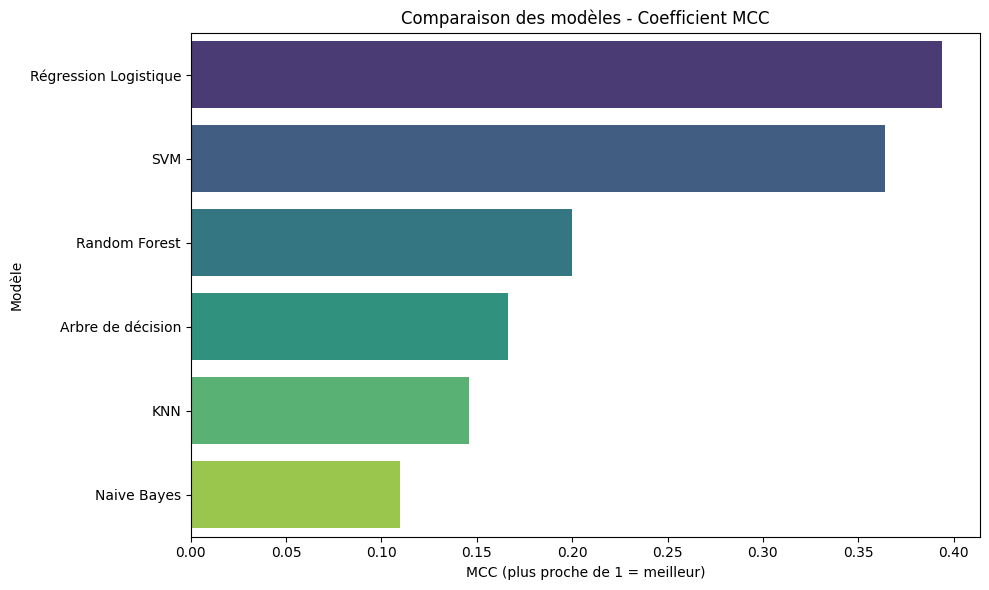

In [42]:
# Tableau comparatif
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="MCC", ascending=False)

print("Classement par MCC (meilleur → moins bon) :")
print(results_df.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="MCC", y="Modèle", palette="viridis")
plt.title("Comparaison des modèles - Coefficient MCC")
plt.xlabel("MCC (plus proche de 1 = meilleur)")
plt.tight_layout()
plt.show()

# Phase 4 : Évaluation et Interprétation

## 4.1 Analyse du meilleur modèle (Régression Logistique)

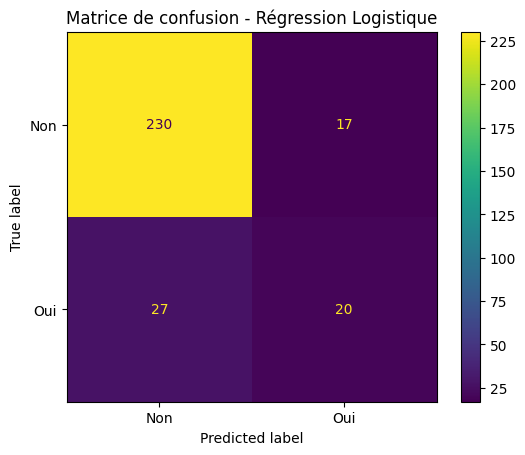

Interprétation :
- Vrais Négatifs (TN) : 230 (bien classés 'Non')
- Vrais Positifs (TP) : 20 (bien classés 'Oui')
- Faux Positifs (FP) : 17 (classés 'Oui' à tort)
- Faux Négatifs (FN) : 27 (classés 'Non' à tort)


In [43]:
# Meilleur modèle : Régression Logistique
best_model = LogisticRegression(random_state=42, max_iter=1000)
best_model.fit(X_train_scaled, y_train_bal)
y_pred_best = best_model.predict(X_test_scaled)

# Matrice de confusion détaillée
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non', 'Oui'])
disp.plot()
plt.title("Matrice de confusion - Régression Logistique")
plt.show()

# Interprétation
print("Interprétation :")
print(f"- Vrais Négatifs (TN) : {cm[0][0]} (bien classés 'Non')")
print(f"- Vrais Positifs (TP) : {cm[1][1]} (bien classés 'Oui')")
print(f"- Faux Positifs (FP) : {cm[0][1]} (classés 'Oui' à tort)")
print(f"- Faux Négatifs (FN) : {cm[1][0]} (classés 'Non' à tort)")

## 4.2 Discussion sur l'overfitting

In [44]:
# Comparaison Train vs Test
y_train_pred = best_model.predict(X_train_scaled)
train_acc = accuracy_score(y_train_bal, y_train_pred)
test_acc = accuracy_score(y_test, y_pred_best)

print(f"Accuracy sur l'entraînement : {train_acc:.4f}")
print(f"Accuracy sur le test : {test_acc:.4f}")
print(f"Écart : {train_acc - test_acc:.4f}")

if train_acc - test_acc > 0.1:
    print("⚠️ Risque d'overfitting détecté (écart > 10%)")
else:
    print("✅ Pas d'overfitting significatif")

Accuracy sur l'entraînement : 0.9219
Accuracy sur le test : 0.8503
Écart : 0.0716
✅ Pas d'overfitting significatif


## 4.3 Facteurs clés de l'attrition

Top 10 des facteurs influençant l'attrition :
                              Feature  Coefficient
33            JobRole_Human Resources    -3.219796
30               EducationField_Other    -2.917182
25  Department_Research & Development    -2.528538
29             EducationField_Medical    -2.477976
27       EducationField_Life Sciences    -2.128358
28           EducationField_Marketing    -2.116416
31    EducationField_Technical Degree    -1.790566
26                   Department_Sales    -1.610487
37          JobRole_Research Director    -1.415985
43                       OverTime_Yes     1.306859


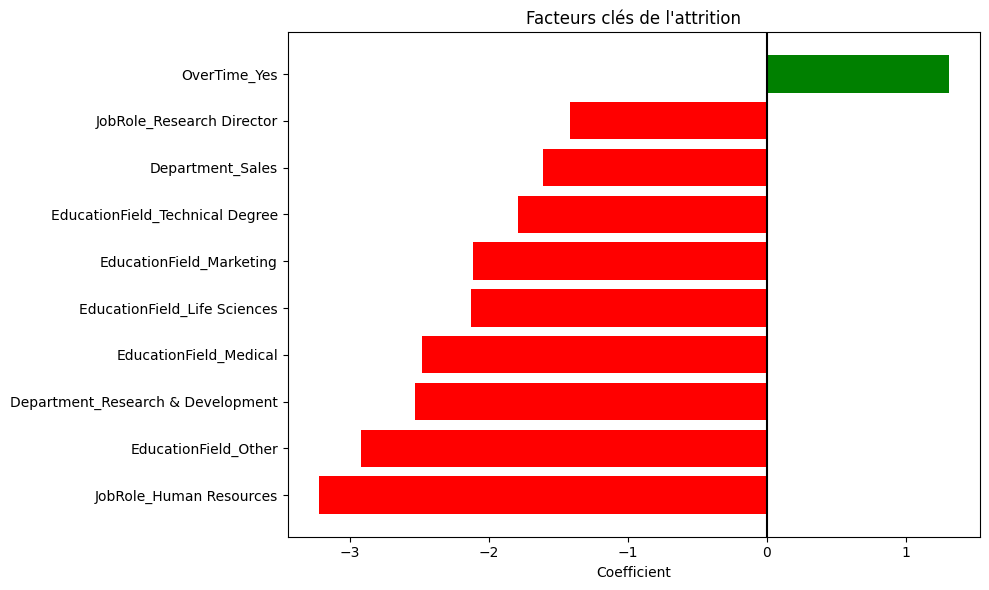

In [45]:
# Récupération des coefficients (Régression Logistique)
coefficients = best_model.coef_[0]
feature_names = X_encoded.columns

# Tri par importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
importance_df['Abs_Coefficient'] = abs(importance_df['Coefficient'])
importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

print("Top 10 des facteurs influençant l'attrition :")
print(importance_df.head(10)[['Feature', 'Coefficient']])

# Visualisation
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10)
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient')
plt.title("Facteurs clés de l'attrition")
plt.axvline(x=0, color='black', linestyle='-')
plt.tight_layout()
plt.show()

In [49]:
# Sauvegarde du modèle et du scaler
import joblib
import os 

# Ré-entraîner le meilleur modèle (Régression Logistique) si nécessaire
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(random_state=42, max_iter=1000)
best_model.fit(X_train_scaled, y_train_bal)

# Sauvegarde des fichiers
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_encoded.columns.tolist(), 'feature_names.pkl')

print("✅ Fichiers sauvegardés avec succès !")
print("   - best_model.pkl")
print("   - scaler.pkl")  
print("   - feature_names.pkl")
print("\n📁 Emplacement :", os.getcwd())

✅ Fichiers sauvegardés avec succès !
   - best_model.pkl
   - scaler.pkl
   - feature_names.pkl

📁 Emplacement : c:\Users\pc\Desktop\SDSI\S02\Data mining\Projet DM
